# 1. Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from xgboost import plot_importance
import lightgbm as lgb


df = pd.read_csv("/kaggle/input/datasets/afifaniks/bangla-music-dataset/dataset.csv")
print(f"Length : {df.shape[0]}")

Length : 1742


In [2]:
df.head(3)

,file_name,zero_crossing,spectral_centroid,spectral_rolloff,spectral_bandwidth,chroma_frequency,rmse,delta,melspectogram,tempo,...,mfcc11,mfcc12,mfcc13,mfcc14,mfcc15,mfcc16,mfcc17,mfcc18,mfcc19,label
0,(Tomake Paowa) - Hridoy Khan & Tasnim Anika F...,125424,1770.889394,3893.575094,2414.810615,0.315795,0.222552,-7.661680e-08,12.977708,172.265625,...,3.164991,-3.867179,5.325016,1.176338,-0.788755,-6.343288,2.488148,0.047027,7.211918,adhunik
1,008. Jai Bole Jete Naire - Jewel (1980).mp3,308658,2549.349989,4986.658880,2193.617981,0.310113,0.156930,8.893313e-08,5.118271,143.554688,...,8.358729,-12.691169,11.393858,-6.176215,9.947330,-6.987708,7.935905,-9.452455,1.582699,adhunik
2,03. Doob Habib ft Mousumi & Mosharraf Karim...,158328,2013.718396,4573.595848,2515.994413,0.301663,0.093736,1.340824e-07,2.497263,103.359375,...,-3.361615,-6.730814,0.184162,-4.139533,4.409801,3.190835,4.862090,-6.406590,-0.705287,adhunik


<BarContainer object of 6 artists>

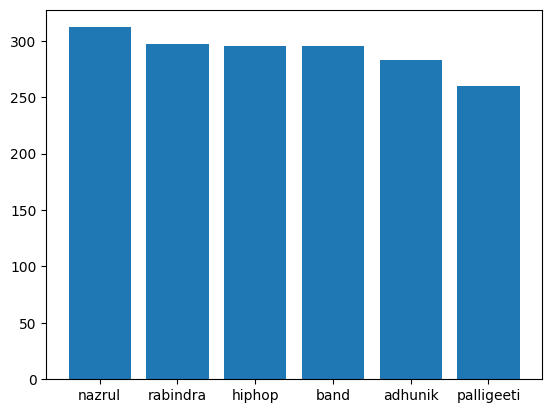

In [3]:
X = df['label'].value_counts()
classes = X.keys()
labels = {}
for c in classes:
    labels[c] = X[c]

plt.bar(labels.keys(), labels.values())

# 2. Preprocessing

In [4]:
X = df.drop(['file_name', 'label'], axis=1)
y = df['label']

In [5]:
# normalization
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X = sc.fit_transform(X)

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8)

# encoding labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.fit_transform(y_test)

In [6]:
print(f"X train Shape : {X_train.shape}")
print(f"X test Shape : {X_test.shape}")

X train Shape : (1393, 29)
X test Shape : (349, 29)


In [7]:
le.classes_

array(['adhunik', 'band', 'hiphop', 'nazrul', 'palligeeti', 'rabindra'],
      dtype=object)

# 3. Training XGBoost

In [8]:
model = XGBClassifier(
    num_class = len(le.classes_),
    eval_metric = 'mlogloss',
    max_depth = 4,
    learning_rate=0.3,
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.3, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None, num_class=6, ...)

In [9]:
# Predict class labels
y_pred_xgb = model.predict(X_test)

# Predict class probabilities
y_prob = model.predict_proba(X_test)


print("\n Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\n Classification Report:\n",
      classification_report(y_test, y_pred_xgb, target_names=le.classes_))

print("\n Predicted class labels:", y_pred_xgb[:5])
print(" Actual class labels   :", y_test[:5])


 Accuracy: 0.7478510028653295

 Classification Report:
               precision    recall  f1-score   support

     adhunik       0.61      0.69      0.64        54
        band       0.77      0.79      0.78        61
      hiphop       0.86      0.83      0.85        66
      nazrul       0.83      0.75      0.79        59
  palligeeti       0.75      0.79      0.77        52
    rabindra       0.67      0.63      0.65        57

    accuracy                           0.75       349
   macro avg       0.75      0.75      0.75       349
weighted avg       0.75      0.75      0.75       349


 Predicted class labels: [2 2 1 2 4]
 Actual class labels   : [2 4 1 0 4]


In [10]:
xgb_report = classification_report(y_test, y_pred_xgb, output_dict=True) 

accuracy = accuracy_score(y_test, y_pred_xgb)
print(f'Accuracy: {accuracy}')

Accuracy: 0.7478510028653295


<Axes: >

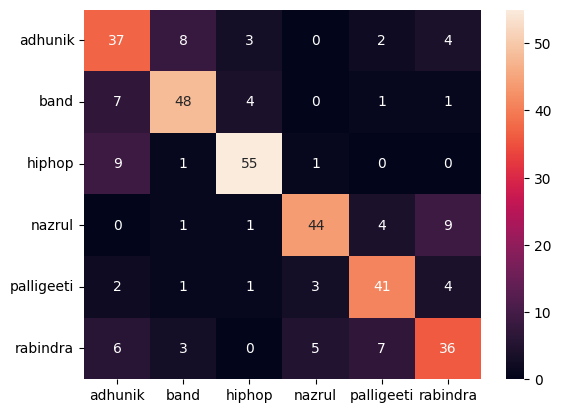

In [11]:
con_mat = confusion_matrix(y_test, y_pred_xgb)
df_cm = pd.DataFrame(con_mat, columns=le.classes_, index=le.classes_)
sn.heatmap(df_cm, annot=True)

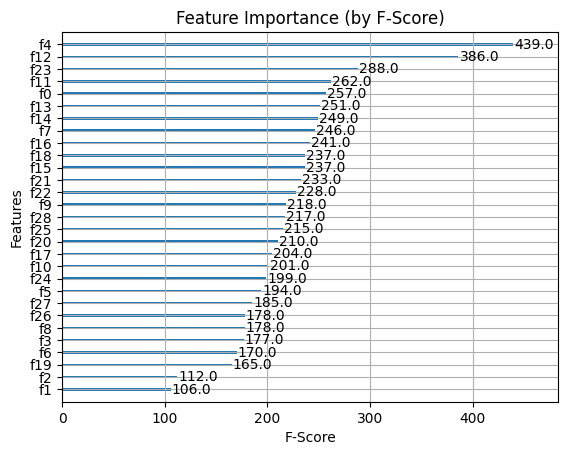

In [12]:
plot_importance(model, importance_type='weight', xlabel='F-Score')
plt.title("Feature Importance (by F-Score)")
plt.show()

# 4.Training lightGBM
- #### *Multiclass Classification using LightGBM*

In [13]:
params = {
    'objective' : 'multiclass',
    'num_class' : len(le.classes_),
    'metric' : 'multi_logloss',
    'verbose' : 0
}

# Create a LightGBM dataset
train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

In [14]:
# Training the Model
num_round = 100
model = lgb.train(params,
                  train_data,
                  num_round,
                  callbacks=[lgb.early_stopping(stopping_rounds=10)],
                  valid_sets=[valid_data])

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[40]	valid_0's multi_logloss: 0.795943


In [15]:
# Getting the model predictions
y_pred = model.predict(X_test,
                       num_iteration=model.best_iteration)
y_pred.shape
y_pred[:4]

array([[1.37007395e-02, 1.14767874e-03, 9.83624809e-01, 4.04020926e-04,
        6.90323802e-04, 4.32428059e-04],
       [5.42966521e-01, 9.41820482e-03, 3.91489161e-01, 3.71070779e-03,
        4.00000384e-02, 1.24153668e-02],
       [1.12842006e-03, 9.86567951e-01, 9.47607589e-03, 6.71306862e-04,
        1.39988700e-03, 7.56358913e-04],
       [4.92221025e-02, 2.28495966e-02, 9.22763712e-01, 1.21232975e-03,
        1.46702753e-03, 2.48523143e-03]])

In [16]:
# Mapping probabilities to find the class
y_pred = np.argmax(y_pred, axis=1)
y_pred[:10]

array([2, 0, 1, 2, 4, 0, 0, 0, 5, 1])

In [17]:
# Get the accuracy score for the prediction values
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

Accuracy: 0.7191977077363897


In [18]:
# Print the classification report for the classes
lgb_report = classification_report(y_test, y_pred,output_dict=True)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.56      0.72      0.63        54
           1       0.79      0.72      0.75        61
           2       0.87      0.80      0.83        66
           3       0.83      0.75      0.79        59
           4       0.70      0.77      0.73        52
           5       0.60      0.54      0.57        57

    accuracy                           0.72       349
   macro avg       0.72      0.72      0.72       349
weighted avg       0.73      0.72      0.72       349



<Axes: >

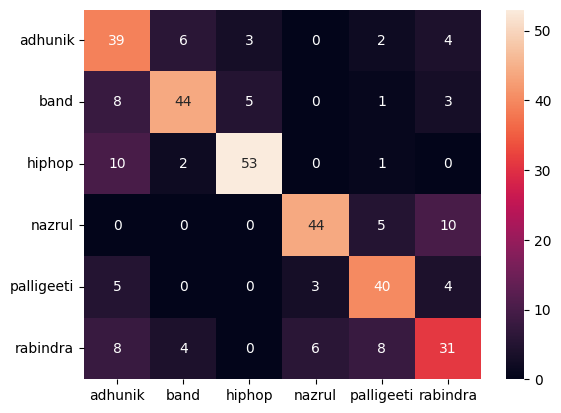

In [19]:
con_mat = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(con_mat, columns=le.classes_, index=le.classes_)
sn.heatmap(df_cm, annot=True)

# 5. Results

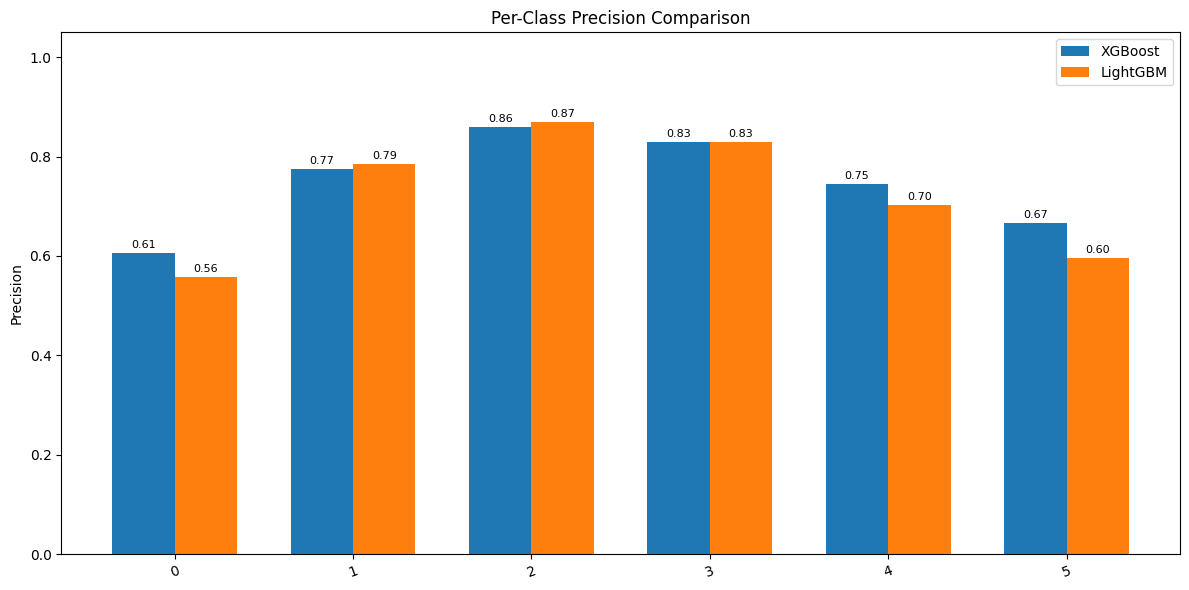

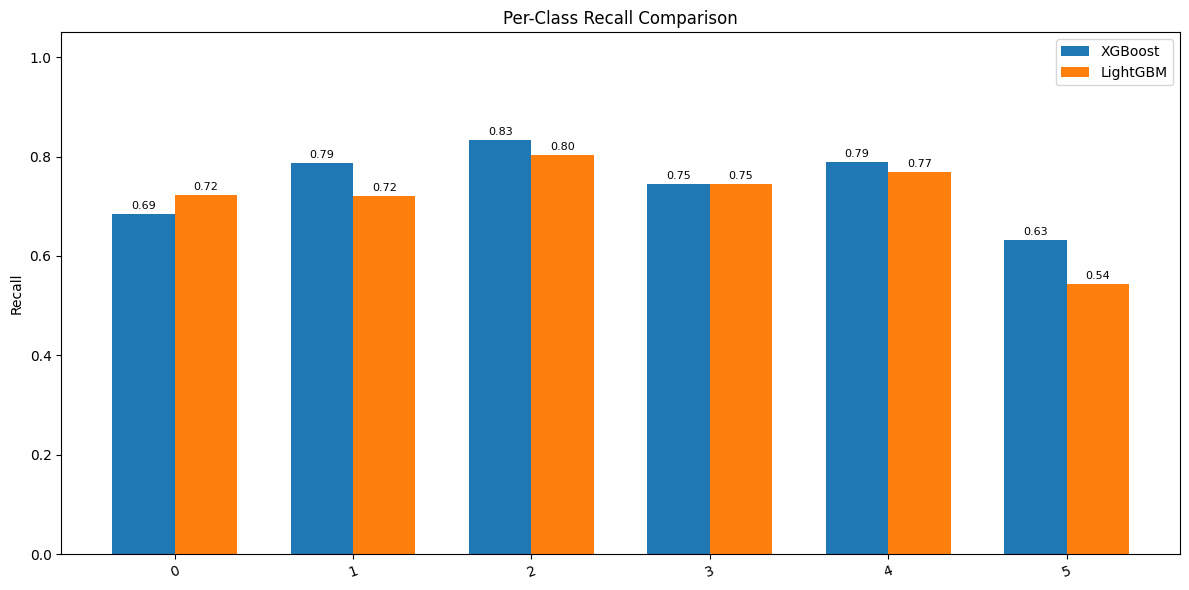

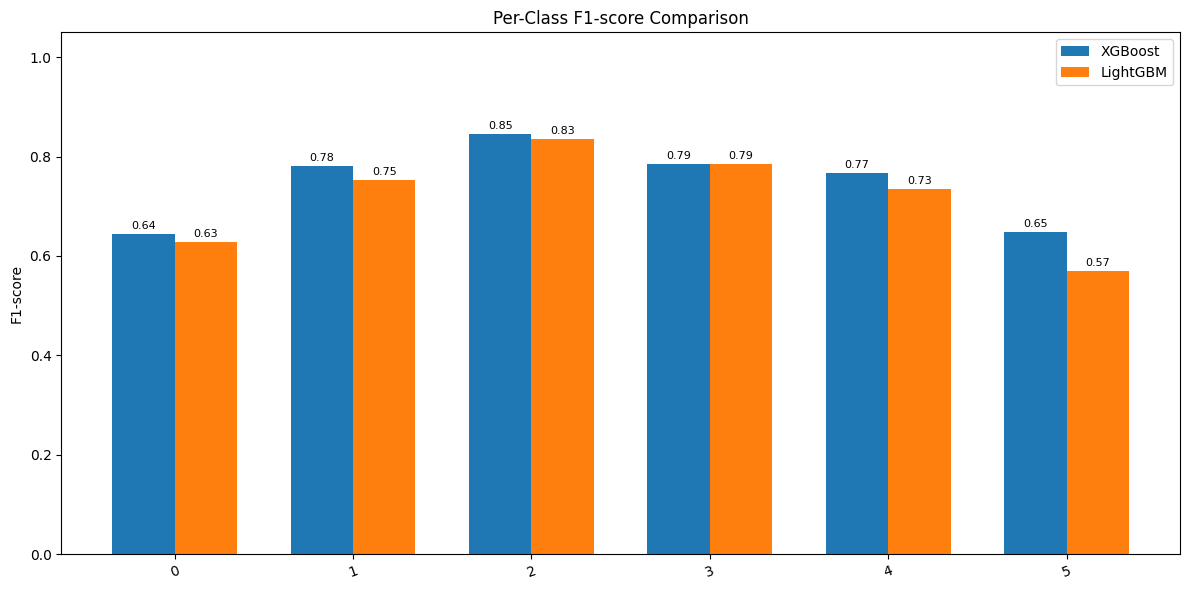

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# classification_report(..., output_dict=True)
# Example:
# xgb_report = classification_report(y_true, y_pred_xgb, output_dict=True)
# lgb_report = classification_report(y_true, y_pred_lgb, output_dict=True)

# ----------------------------
# Overall Metrics
# ----------------------------
overall_metrics = [
    "accuracy",
    "macro avg",
    "weighted avg"
]

metric_names = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Weighted Precision",
    "Weighted Recall",
    "Weighted F1"
]

xgb_values = [
    xgb_report["accuracy"],
    xgb_report["macro avg"]["precision"],
    xgb_report["macro avg"]["recall"],
    xgb_report["macro avg"]["f1-score"],
    xgb_report["weighted avg"]["precision"],
    xgb_report["weighted avg"]["recall"],
    xgb_report["weighted avg"]["f1-score"],
]

lgb_values = [
    lgb_report["accuracy"],
    lgb_report["macro avg"]["precision"],
    lgb_report["macro avg"]["recall"],
    lgb_report["macro avg"]["f1-score"],
    lgb_report["weighted avg"]["precision"],
    lgb_report["weighted avg"]["recall"],
    lgb_report["weighted avg"]["f1-score"],
]

x = np.arange(len(metric_names))
width = 0.35

# ----------------------------
# Per-Class Comparison Function
# ----------------------------

def compare_metric(metric):
    classes = [k for k in xgb_report.keys()
               if k not in ("accuracy","macro avg","weighted avg")]

    xgb_scores = [xgb_report[c][metric] for c in classes]
    lgb_scores = [lgb_report[c][metric] for c in classes]

    x = np.arange(len(classes))
    width = 0.35

    plt.figure(figsize=(12,6))

    plt.bar(x-width/2, xgb_scores, width, label='XGBoost')
    plt.bar(x+width/2, lgb_scores, width, label='LightGBM')

    plt.xticks(x, classes, rotation=20)
    plt.ylabel(metric.capitalize())
    plt.ylim(0,1.05)
    plt.title(f"Per-Class {metric.capitalize()} Comparison")
    plt.legend()

    for i,v in enumerate(xgb_scores):
        plt.text(i-width/2,v+0.01,f"{v:.2f}",ha='center',fontsize=8)

    for i,v in enumerate(lgb_scores):
        plt.text(i+width/2,v+0.01,f"{v:.2f}",ha='center',fontsize=8)

    plt.tight_layout()
    plt.show()


compare_metric("precision")
compare_metric("recall")
compare_metric("f1-score")